# Exploration of the Global Multi-resolution Terrain Elevation Data

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

In [2]:
GMTED_MN_DIR = "../datasets/GMTED2010/mn30_grd"
GMTED_SD_DIR = "../datasets/GMTED2010/sd30_grd"

## Visualizations

In [ ]:
def plot_elevation(data_dir, bounds, ax=None):
    """Plot mean elevation from GMTED2010 data within specified bounds."""
    with rasterio.open(data_dir) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
        extent = rasterio.windows.bounds(window, src.transform)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    img = ax.imshow(data, extent=extent, cmap='terrain', origin='upper')
    plt.colorbar(img, ax=ax, label='Mean Elevation (m)')
    return ax

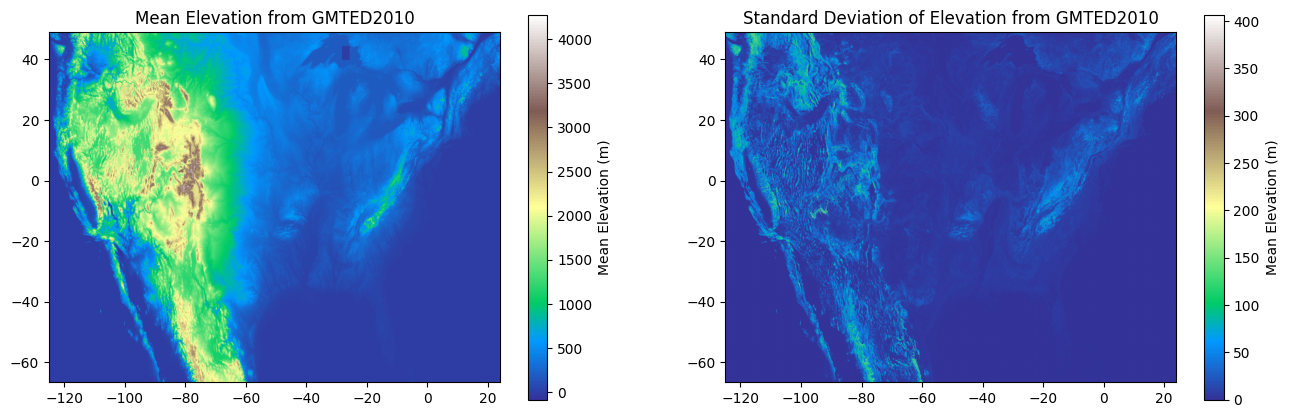

In [16]:
# plot meand and std elevation subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0] = plot_elevation(GMTED_MN_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[0])
ax[0].set_title('Mean Elevation from GMTED2010')
ax[1] = plot_elevation(GMTED_SD_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[1])
ax[1].set_title('Standard Deviation of Elevation from GMTED2010')
plt.show()


## Elevation per point

In [17]:
def gmted_features(lat, lon, radius_km, gmted_dirs):
    """Extract GMTED2010 features mean and std elevation around a point, linearly interpolating from the closest points."""
    features = {}
    for gmted_dir in gmted_dirs:
        with rasterio.open(gmted_dir) as src:
            # Convert radius from km to degrees (approximation)
            radius_deg = radius_km / 111.32
            bounds = (lon - radius_deg, lat - radius_deg, lon + radius_deg, lat + radius_deg)
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window)
            mean_val = np.nanmean(data)
            std_val = np.nanstd(data)
            if 'mn' in os.path.basename(gmted_dir):
                features['mean_elevation'] = mean_val
            elif 'sd' in os.path.basename(gmted_dir):
                features['std_elevation'] = std_val
    return features   
    

In [18]:
gmted_features(
    lat=39.7392,
    lon=-104.9903,   # Denver
    radius_km=10,
    gmted_dirs=[GMTED_MN_DIR, GMTED_SD_DIR]
)

{'mean_elevation': np.float64(1624.23347107438),
 'std_elevation': np.float64(2.2504040800098344)}

## Add elevation to the dataset

In [ ]:
# load dataset
# drop everything apart index, lat and long
# add coverage col
# save to file, ready to be merged